<a href="https://colab.research.google.com/github/Mandar-Ghatekar/IEX-Electricity-Market-Analysis/blob/main/IEX_Electicity_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

file_path = 'DAM_Market Snapshot.xlsx'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")
df = pd.read_excel('DAM_Market Snapshot.xlsx')

print(f"Total rows (Time Blocks): {df.shape[0]}")
print(f"Total data columns: {df.shape[1]}")

display(df.head(20))

Total rows (Time Blocks): 105
Total data columns: 8


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Market Snapshot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date: 15-06-2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
4,15-06-2026,1,00:00 - 00:15,13866.10,8305.30,6036.00,6036.00,5499.53
5,15-06-2026,1,00:15 - 00:30,13674.90,8648.40,5972.50,5972.50,5450.63
6,15-06-2026,1,00:30 - 00:45,13469.40,8898.80,5883.09,5883.09,4872.41
7,15-06-2026,1,00:45 - 01:00,13737.70,9245.80,6573.20,6573.20,5000.10
8,15-06-2026,2,01:00 - 01:15,13765.40,9660.50,6806.50,6806.50,5000.02
9,15-06-2026,2,01:15 - 01:30,12961.50,9718.60,6751.50,6751.50,4999.19


In [ ]:
import pandas as pd
# Loading Day-Ahead Market (DAM) data and isolating a single 24-hour cycle (96 blocks)
df1 = pd.read_excel('DAM_Market Snapshot.xlsx',skiprows=4)
display(df1.head(10))
df1 = df1.iloc[:96]
total_rows = df1.shape[0]
total_columns = df1.shape[1]
print(f"Total rows are {total_rows}")
print(f"Total columns are {total_columns}")

print("\n=== Checking DATA TYPE  ===")
print(df1.dtypes)
df1['Purchase Bid (MW)'] = pd.to_numeric(df1['Purchase Bid (MW)'],errors = 'coerce')
df1['Sell Bid (MW)'] = pd.to_numeric(df1['Sell Bid (MW)'], errors='coerce')

print("\n=== RE-CHECKING DATA TYPES ===")
print(df1.dtypes)
missing_values = df1.isnull().sum()
print(missing_values)
print(df1.describe())


,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
0,15-06-2026,1,00:00 - 00:15,13866.10,8305.30,6036.00,6036.00,5499.53
1,15-06-2026,1,00:15 - 00:30,13674.90,8648.40,5972.50,5972.50,5450.63
2,15-06-2026,1,00:30 - 00:45,13469.40,8898.80,5883.09,5883.09,4872.41
3,15-06-2026,1,00:45 - 01:00,13737.70,9245.80,6573.20,6573.20,5000.10
4,15-06-2026,2,01:00 - 01:15,13765.40,9660.50,6806.50,6806.50,5000.02
5,15-06-2026,2,01:15 - 01:30,12961.50,9718.60,6751.50,6751.50,4999.19
6,15-06-2026,2,01:30 - 01:45,12502.40,9822.20,6399.00,6399.00,4576.33
7,15-06-2026,2,01:45 - 02:00,11909.40,10386.30,6263.00,6263.00,4449.65
8,15-06-2026,3,02:00 - 02:15,11252.30,11142.80,5915.80,5915.80,4295.07
9,15-06-2026,3,02:15 - 02:30,11202.30,11373.50,5946.60,5946.60,4002.74


Total rows are 96
Total columns are 8

=== Checking DATA TYPE  ===
Date                            object
Hour                            object
Time Block                      object
Purchase Bid (MW)               object
Sell Bid (MW)                   object
MCV (MW)                        object
Final Scheduled Volume (MW)     object
MCP (Rs/MWh) *                 float64
dtype: object

=== RE-CHECKING DATA TYPES ===
Date                            object
Hour                            object
Time Block                      object
Purchase Bid (MW)              float64
Sell Bid (MW)                  float64
MCV (MW)                        object
Final Scheduled Volume (MW)     object
MCP (Rs/MWh) *                 float64
dtype: object
Date                           0
Hour                           0
Time Block                     0
Purchase Bid (MW)              0
Sell Bid (MW)                  0
MCV (MW)                       0
Final Scheduled Volume (MW)    0
MCP (Rs/MWh) *    

In [ ]:
# Making the data suitable for the future model training
df1['start_time'] = df1['Time Block'].str.split(' - ').str[0]
df1['Timestamp_Str'] = df1['Date'] + ' ' + df1['start_time']
df1['Timestamp'] = pd.to_datetime(df1['Timestamp_Str'], format='%d-%m-%Y %H:%M')
df1.set_index('Timestamp', inplace=True)
df1.drop(columns=['start_time', 'Timestamp_Str'], inplace=True)
df1.drop(columns=['Date', 'Time Block', 'Hour'], inplace=True, errors='ignore')
df1.head()



,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
Timestamp,,,,,
2026-06-15 00:00:00,13866.1,8305.3,6036.00,6036.00,5499.53
2026-06-15 00:15:00,13674.9,8648.4,5972.50,5972.50,5450.63
2026-06-15 00:30:00,13469.4,8898.8,5883.09,5883.09,4872.41
2026-06-15 00:45:00,13737.7,9245.8,6573.20,6573.20,5000.10
2026-06-15 01:00:00,13765.4,9660.5,6806.50,6806.50,5000.02


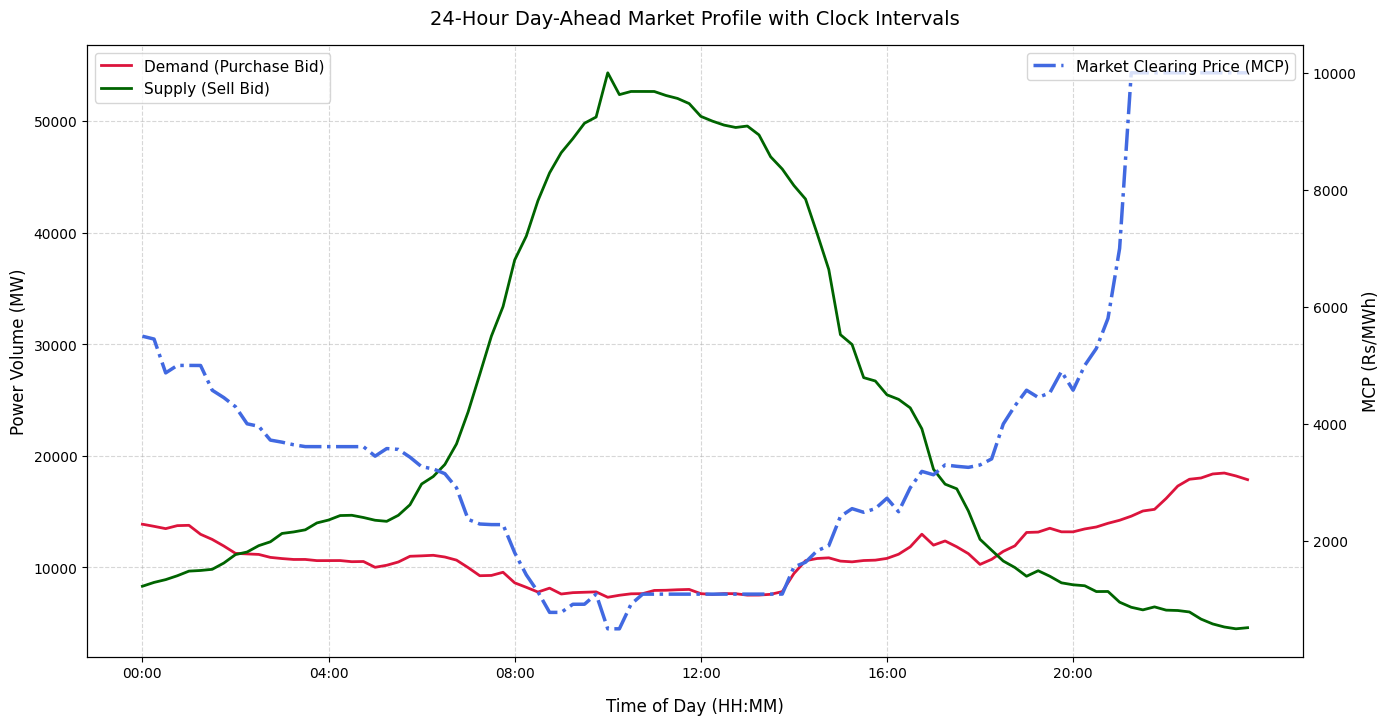

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df1.index = pd.to_datetime(df1.index)
df1['Time_Stamp'] = df1.index.strftime('%H:%M')
fig, ax1 = plt.subplots(figsize=(14, 7))

x_positions = range(len(df1))
ax1.plot(x_positions, df1['Purchase Bid (MW)'], label='Demand (Purchase Bid)', color='crimson', lw=2)
ax1.plot(x_positions, df1['Sell Bid (MW)'], label='Supply (Sell Bid)', color='darkgreen', lw=2)

ax1.set_xlabel('Time of Day (HH:MM)', fontsize=12, labelpad=12)
ax1.set_ylabel('Power Volume (MW)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(x_positions, df1['MCP (Rs/MWh) *'], label='Market Clearing Price (MCP)', color='royalblue', lw=2.5, linestyle='-.')
ax2.set_ylabel('MCP (Rs/MWh)', fontsize=12)

tick_indices = list(range(0, len(df1), 16))
tick_labels = [df1['Time_Stamp'].iloc[i] for i in tick_indices]

ax1.set_xticks(tick_indices)
ax1.set_xticklabels(tick_labels, fontsize=10)

plt.tight_layout()

plt.title('24-Hour Day-Ahead Market Profile with Clock Intervals', fontsize=14, pad=15)
ax1.legend(loc='upper left', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)

plt.show()

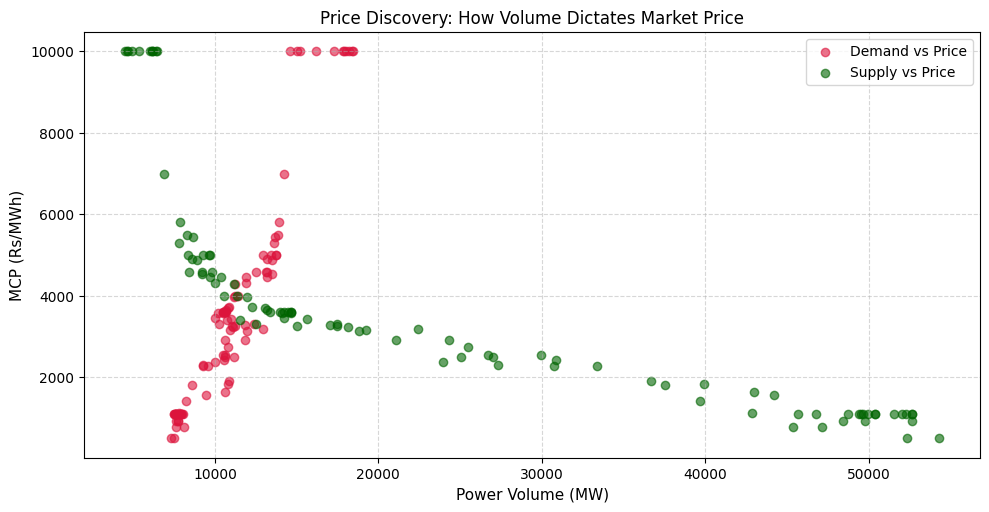

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Plot Demand vs Price as dots, and Supply vs Price as dots
ax.scatter(df1['Purchase Bid (MW)'], df1['MCP (Rs/MWh) *'], color='crimson', alpha=0.6, label='Demand vs Price')
ax.scatter(df1['Sell Bid (MW)'], df1['MCP (Rs/MWh) *'], color='darkgreen', alpha=0.6, label='Supply vs Price')

ax.set_xlabel('Power Volume (MW)', fontsize=11)
ax.set_ylabel('MCP (Rs/MWh)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.title('Price Discovery: How Volume Dictates Market Price', fontsize=12)
plt.show()

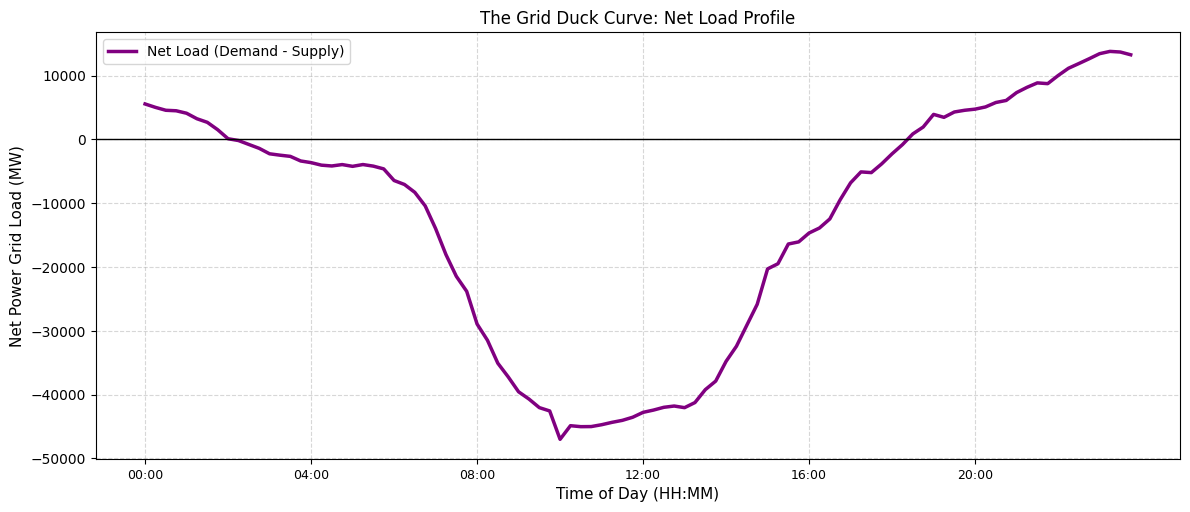

In [ ]:
import matplotlib.pyplot as plt

df1['Net_Load'] = df1['Purchase Bid (MW)'] - df1['Sell Bid (MW)']

fig, ax = plt.subplots(figsize=(12, 5))

x_positions = range(len(df1))
ax.plot(x_positions, df1['Net_Load'], color='purple', lw=2.5, label='Net Load (Demand - Supply)')
ax.axhline(0, color='black', lw=1, linestyle='-')

ax.set_xlabel('Time of Day (HH:MM)', fontsize=11)
ax.set_ylabel('Net Power Grid Load (MW)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

tick_indices = list(range(0, len(df1), 16))
tick_labels = [df1['Time_Stamp'].iloc[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, fontsize=9)

plt.tight_layout()
plt.title('The Grid Duck Curve: Net Load Profile', fontsize=12)
plt.legend()
plt.show()

In [ ]:
df1['Demand_Supply_Gap'] = df1['Purchase Bid (MW)'] - df1['Sell Bid (MW)']
df1['Demand_Supply_Gap_Lag1'] = df1['Demand_Supply_Gap'].shift(1)
df_ml = df1.dropna().copy()
# Extracting our target variable
y = df_ml['MCP (Rs/MWh) *']

X = df_ml[['Demand_Supply_Gap_Lag1']]

import xgboost as xgb
from xgboost import XGBRegressor
split_index = 80
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Number of predicted prices:", len(y_pred))

df_results = X_test.copy()

df_results['True_Price'] = y_test
df_results['Predicted_Price'] = y_pred
print(X_test.index)
df_results = pd.DataFrame({'True_Price': y_test, 'Predicted_Price': y_pred}, index=X_test.index)
print(df_results.head())

Number of predicted prices: 15
DatetimeIndex(['2026-06-15 20:15:00', '2026-06-15 20:30:00',
               '2026-06-15 20:45:00', '2026-06-15 21:00:00',
               '2026-06-15 21:15:00', '2026-06-15 21:30:00',
               '2026-06-15 21:45:00', '2026-06-15 22:00:00',
               '2026-06-15 22:15:00', '2026-06-15 22:30:00',
               '2026-06-15 22:45:00', '2026-06-15 23:00:00',
               '2026-06-15 23:15:00', '2026-06-15 23:30:00',
               '2026-06-15 23:45:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
                     True_Price  Predicted_Price
Timestamp                                       
2026-06-15 20:15:00     4999.63      4764.444824
2026-06-15 20:30:00     5290.43      4806.838867
2026-06-15 20:45:00     5803.68      5255.770508
2026-06-15 21:00:00     6999.50      5255.770508
2026-06-15 21:15:00    10000.00      5255.770508


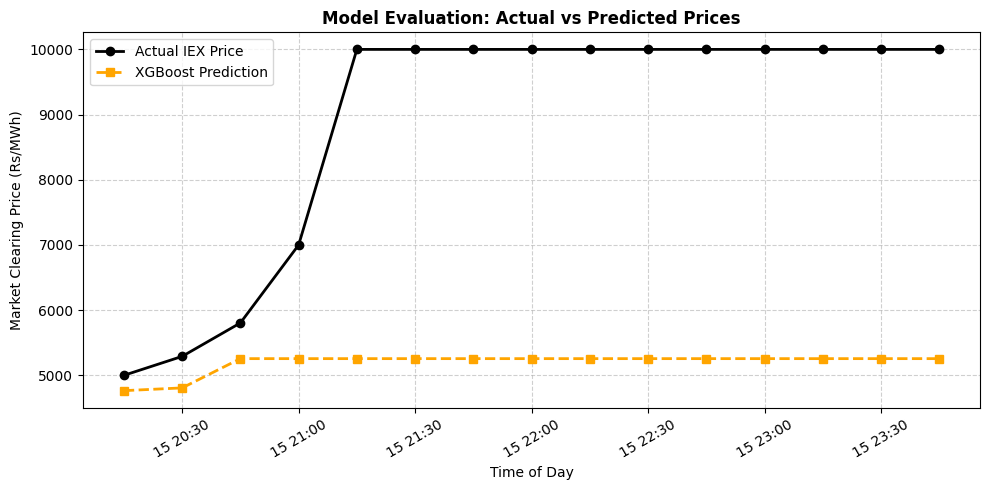

In [ ]:

# Plotting the Actual vs Predicted prices directly using our DatetimeIndex
plt.figure(figsize=(10, 5))

plt.plot(df_results.index, df_results['True_Price'], label='Actual IEX Price', color='black', marker='o', lw=2)
plt.plot(df_results.index, df_results['Predicted_Price'], label='XGBoost Prediction', color='orange', linestyle='--', marker='s', lw=2)

plt.xlabel('Time of Day')
plt.ylabel('Market Clearing Price (Rs/MWh)')
plt.title('Model Evaluation: Actual vs Predicted Prices', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse:.2f} Rs/MWh")

Model RMSE: 4092.39 Rs/MWh


In [20]:
import pandas as pd
import numpy as np
import os

file_path = 'DAM_Market Snapshot (6).xlsx'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")

df1 = pd.read_excel(file_path, skiprows=4)
df1 = df1.dropna(subset=['Date', 'Time Block']).iloc[:2981]

numeric_cols = [
    'Purchase Bid (MW)', 'Sell Bid (MW)', 'MCP (Rs/MWh) *',
    'MCV (MW)', 'Final Scheduled Volume (MW)'
]
for col in numeric_cols:
    if col in df1.columns:
        df1[col] = pd.to_numeric(df1[col].astype(str).str.replace(',', ''), errors='coerce')

df1 = df1.dropna(subset=['Purchase Bid (MW)', 'Sell Bid (MW)', 'MCP (Rs/MWh) *'])

df1['start_time'] = df1['Time Block'].str.split(' - ').str[0]
df1['Timestamp_Str'] = df1['Date'].astype(str) + ' ' + df1['start_time']
df1['Timestamp'] = pd.to_datetime(df1['Timestamp_Str'], dayfirst=True, errors='coerce')

df1 = df1.dropna(subset=['Timestamp']).set_index('Timestamp').sort_index()

df1['Demand_Supply_Gap'] = df1['Purchase Bid (MW)'] - df1['Sell Bid (MW)']
df1['Demand_Supply_Gap_Lag1'] = df1['Demand_Supply_Gap'].shift(1)
df1['Hour'] = df1.index.hour

df1.drop(columns=['start_time', 'Timestamp_Str', 'Date', 'Time Block'], inplace=True, errors='ignore')
df1 = df1.dropna()

print(f"Total Rows: {df1.shape[0]} | Total Columns: {df1.shape[1]}")
print(f"Timeline Bounds: {df1.index.min()} to {df1.index.max()}")
print(f"Is Chronological: {df1.index.is_monotonic_increasing}")
print(f"Missing Values:\n{df1.isnull().sum()}")
print(f"\nFinal Column Types:\n{df1.dtypes}")
print(df1.head())

Total Rows: 2975 | Total Columns: 8
Timeline Bounds: 2026-05-25 00:15:00 to 2026-06-24 23:45:00
Is Chronological: True
Missing Values:
Hour                           0
Purchase Bid (MW)              0
Sell Bid (MW)                  0
MCV (MW)                       0
Final Scheduled Volume (MW)    0
MCP (Rs/MWh) *                 0
Demand_Supply_Gap              0
Demand_Supply_Gap_Lag1         0
dtype: int64

Final Column Types:
Hour                             int32
Purchase Bid (MW)              float64
Sell Bid (MW)                  float64
MCV (MW)                       float64
Final Scheduled Volume (MW)    float64
MCP (Rs/MWh) *                 float64
Demand_Supply_Gap              float64
Demand_Supply_Gap_Lag1         float64
dtype: object
                     Hour  Purchase Bid (MW)  Sell Bid (MW)  MCV (MW)  \
Timestamp                                                               
2026-05-25 00:15:00     0            33254.6         2182.4   2124.39   
2026-05-25 00:30:00   


=== MODEL PERFORMANCE VALUATION ===
Old 1-Day Baseline RMSE: 4092.39 Rs/MWh
New Multi-Day Model RMSE: 842.89 Rs/MWh


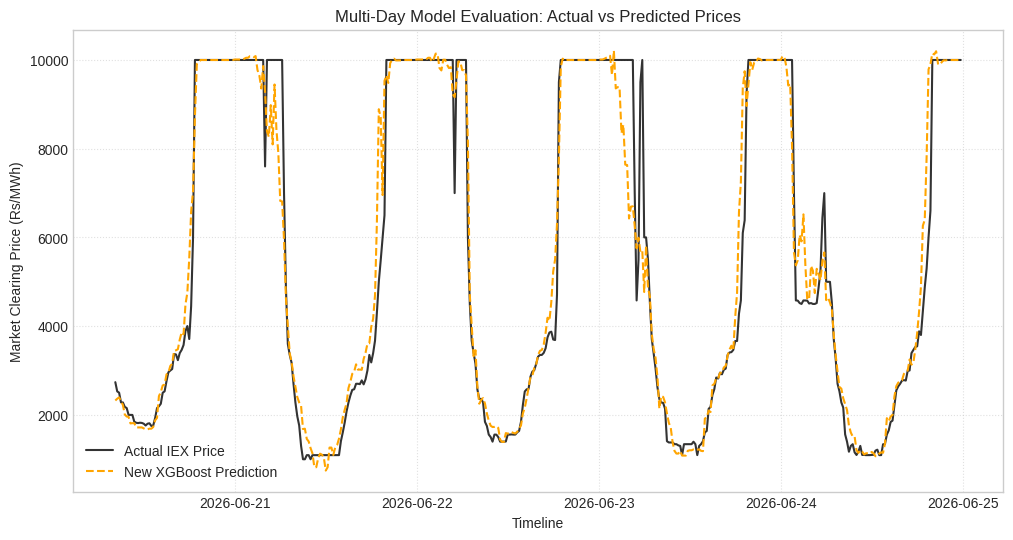

In [21]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Train multi-day XGBoost regressor using engineered feature matrix and evaluate historical backtest tracking
features = ['Purchase Bid (MW)', 'Sell Bid (MW)', 'Demand_Supply_Gap', 'Demand_Supply_Gap_Lag1', 'Hour']
target = 'MCP (Rs/MWh) *'

X = df1[features]
y = df1[target]

split_idx = int(len(df1) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

new_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\n=== MODEL PERFORMANCE VALUATION ===")
print(f"Old 1-Day Baseline RMSE: 4092.39 Rs/MWh")
print(f"New Multi-Day Model RMSE: {new_rmse:.2f} Rs/MWh")

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual IEX Price', color='black', alpha=0.8)
plt.plot(y_test.index, y_pred, label='New XGBoost Prediction', color='orange', linestyle='--')
plt.title('Multi-Day Model Evaluation: Actual vs Predicted Prices')
plt.ylabel('Market Clearing Price (Rs/MWh)')
plt.xlabel('Timeline')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

=== ROLLING FEATURE PERFORMANCE ===
New Rolling RMSE: 855.12 Rs/MWh


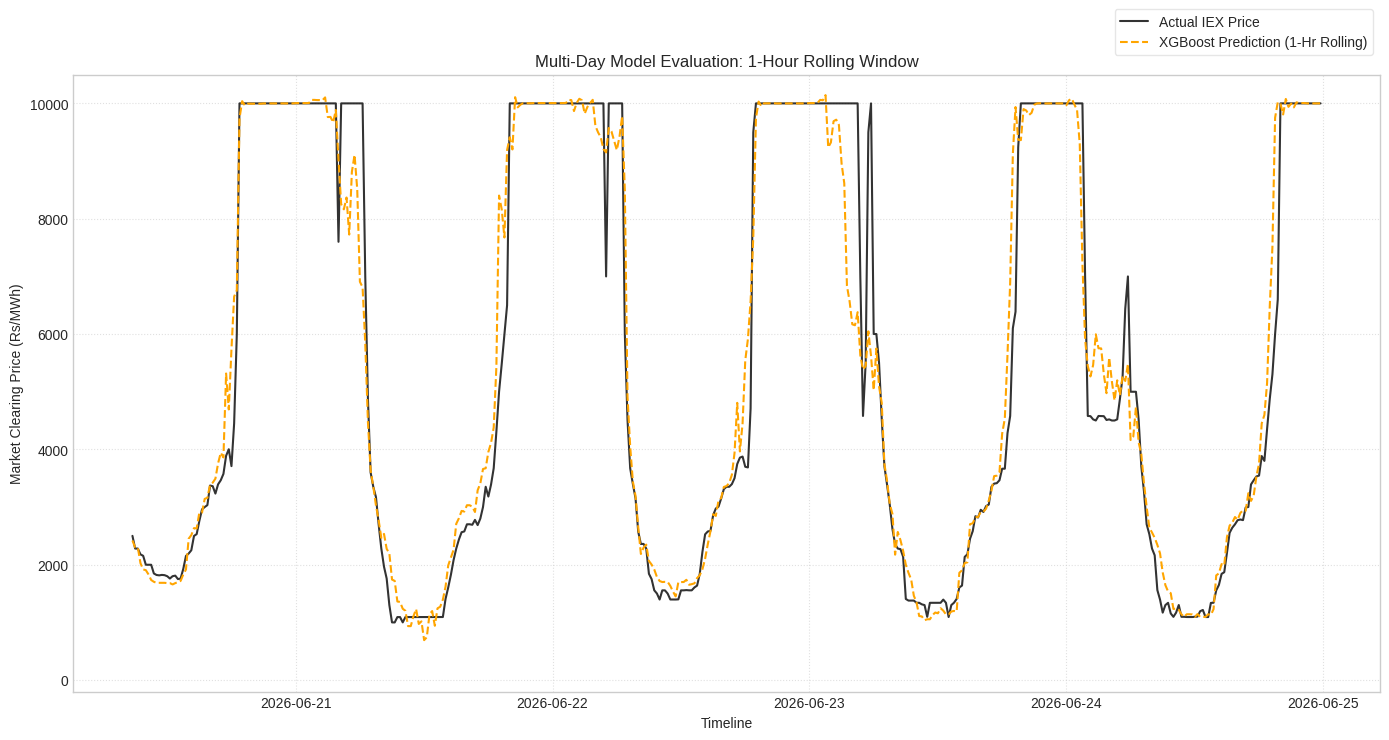

In [24]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Implement 1-hour rolling average window on demand-supply gap to capture near-term market momentum
df1['Gap_Roll4'] = df1['Demand_Supply_Gap'].shift(1).rolling(window=4).mean()
df_ml = df1.dropna().copy()

features = ['Purchase Bid (MW)', 'Sell Bid (MW)', 'Demand_Supply_Gap', 'Demand_Supply_Gap_Lag1', 'Gap_Roll4', 'Hour']
target = 'MCP (Rs/MWh) *'

X = df_ml[features]
y = df_ml[target]

split_idx = int(len(df_ml) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rolling_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"=== ROLLING FEATURE PERFORMANCE ===")
print(f"New Rolling RMSE: {rolling_rmse:.2f} Rs/MWh")

fig, ax = plt.subplots(figsize=(14, 7.5), dpi=100)
ax.plot(y_test.index, y_test.values, label='Actual IEX Price', color='black', alpha=0.8)
ax.plot(y_test.index, y_pred, label='XGBoost Prediction (1-Hr Rolling)', color='orange', linestyle='--')

ax.set_title('Multi-Day Model Evaluation: 1-Hour Rolling Window')
ax.set_ylabel('Market Clearing Price (Rs/MWh)')
ax.set_xlabel('Timeline')

ax.legend(loc='lower right', bbox_to_anchor=(1.0, 1.02), frameon=True, facecolor='white', edgecolor='#E0E0E0')
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_ylim(-200, 10500)

plt.tight_layout()
plt.show()

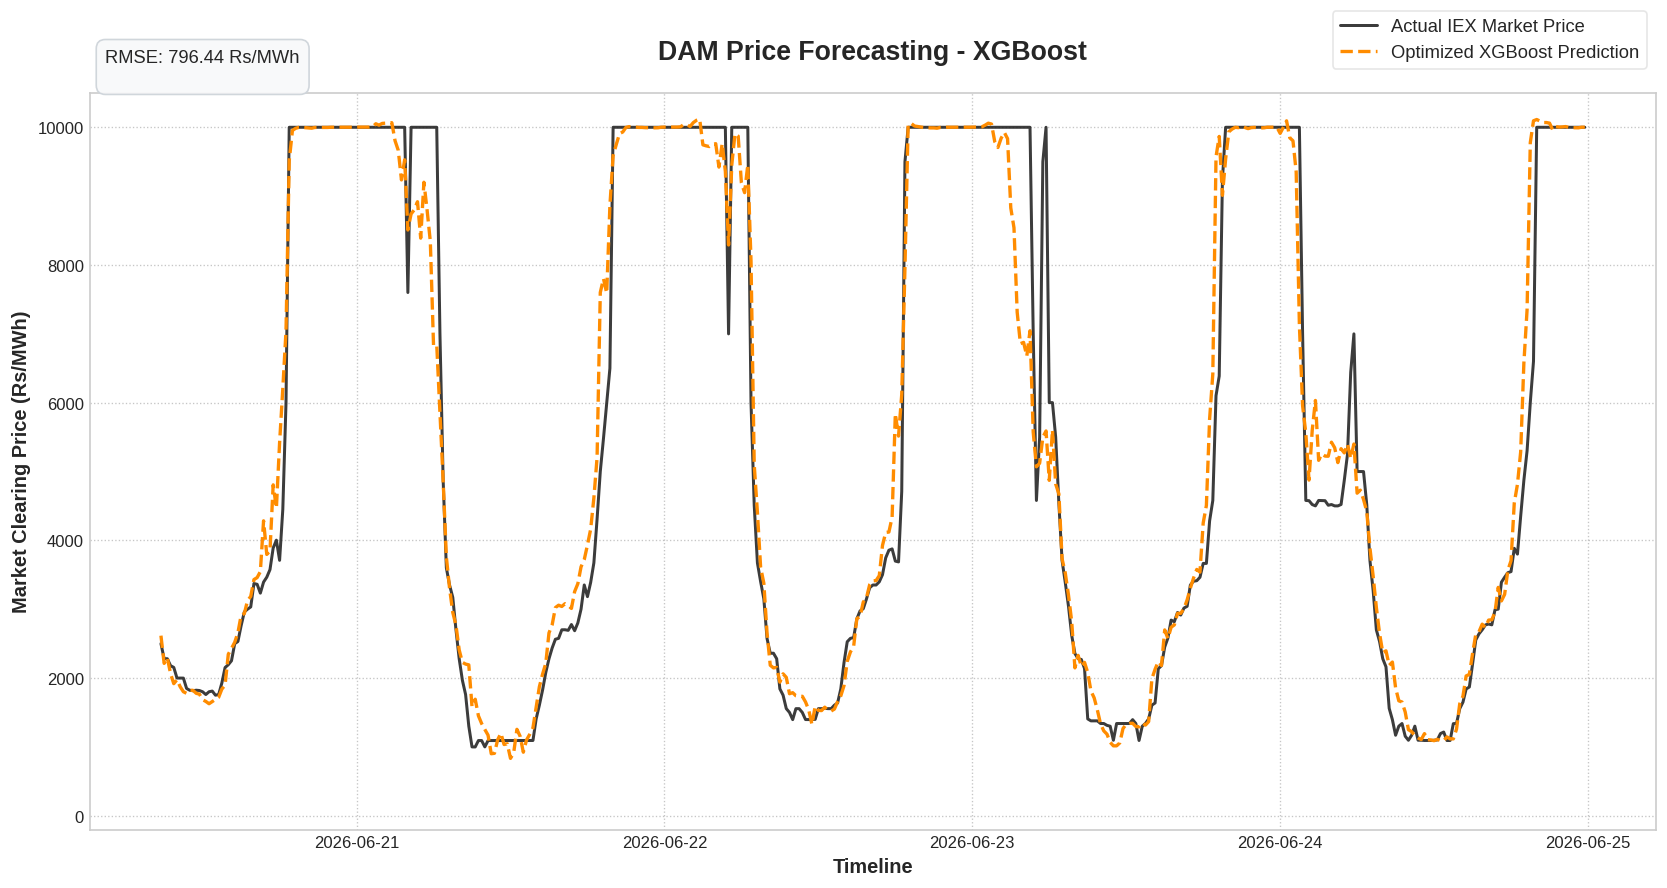

In [27]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Implement a 3-hour rolling average window on the demand-supply gap to capture longer-term structural grid trends
df1['Gap_Roll12'] = df1['Demand_Supply_Gap'].shift(1).rolling(window=12).mean()
df_ml = df1.dropna().copy()

features = ['Purchase Bid (MW)', 'Sell Bid (MW)', 'Demand_Supply_Gap', 'Gap_Roll12', 'Hour']
target = 'MCP (Rs/MWh) *'

X = df_ml[features]
y = df_ml[target]

split_idx = int(len(df_ml) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
fixed_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Render polished evaluation visualization for portfolio export
fig, ax = plt.subplots(figsize=(14, 7.5), dpi=120)
ax.plot(y_test.index, y_test.values, label='Actual IEX Market Price', color='#1A1A1A', linewidth=1.8, alpha=0.85)
ax.plot(y_test.index, y_pred, label='Optimized XGBoost Prediction', color='#FF8C00', linestyle='--', linewidth=2.0)

ax.set_title('DAM Price Forecasting - XGBoost', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Market Clearing Price (Rs/MWh)', fontsize=12, fontweight='bold')
ax.set_xlabel('Timeline', fontsize=12, fontweight='bold')

metric_text = (
    f"RMSE: {fixed_rmse:.2f} Rs/MWh\n"
)
props = dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA', alpha=0.95, edgecolor='#CED4DA')
ax.text(0.01, 1.06, metric_text, transform=ax.transAxes, fontsize=11, fontweight='medium', bbox=props, verticalalignment='top')

ax.legend(loc='lower right', bbox_to_anchor=(1.0, 1.02), frameon=True, facecolor='white', edgecolor='#E0E0E0', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6, color='#A0A0A0')
ax.set_ylim(-200, 10500)

plt.tight_layout()
plt.show()